# پیش‌بینی قیمت آپارتمان در تهران

این نوت‌بوک شامل تحلیل، پاکسازی و مدل‌سازی برای پیش‌بینی قیمت (به دلار) حدود ۳۴۰۰ آپارتمان واقعی در تهران است.

**ویژگی‌های دیتاست:**
- Area: متراژ (متر مربع)
- Room: تعداد اتاق خواب
- Parking / Warehouse / Elevator: امکانات (بولی)
- Address: منطقه تقریبی در تهران
- Price / Price(USD): قیمت به تومان و دلار (هدف پیش‌بینی)

 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb

In [7]:
pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   - -------------------------------------- 3.4/69.5 MB 18.5 MB/s eta 0:00:04
   --------- ------------------------------ 17.0/69.5 MB 42.9 MB/s eta 0:00:02
   ------------------- -------------------- 33.8/69.5 MB 55.1 MB/s eta 0:00:01
   ----------------------------- ---------- 51.6/69.5 MB 62.2 MB/s eta 0:00:01
   ---------------------------------------  69.2/69.5 MB 66.1 MB/s eta 0:00:01
   ---------------------------------------- 69.5/69.5 MB 55.7 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

## ۱. بارگذاری و بررسی اولیه داده

In [6]:
import pandas as pd

df = pd.read_csv("khane.csv")
df.head

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


print('shape', df.shape)
df.head()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   object 
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   object 
 6   Price       3479 non-null   float64
 7   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(2), int64(1), object(2)
memory usage: 146.2+ KB


In [13]:
print('Sum of empty addresses:', df['Address'].isnull().sum())
df['Area'].head(10)

Sum of empty addresses: 23


0     63
1     60
2     79
3     95
4    123
5     70
6     87
7     59
8     54
9     71
Name: Area, dtype: object

## ۲. پاکسازی داده

### مشکل ۱: ستون Area به صورت رشته و شامل مقادیر اشتباه (کاما دار / اعداد نجومی)
برخی مقادیر Area در واقع همان مقدار Price هستند که به اشتباه در ستون متراژ وارد شده‌اند (مثلاً «3,310,000,000»).

### مشکل ۲: مقادیر خالی در Address

In [18]:
def clean_area(x):
    try:
        return float(str(x).replace(',', '').strip())
    except:
        return np.nan

df['Area'] = df['Area'].apply(clean_area)
print('مقادیر نامعتبر بعد از تبدیل:', df['Area'].isnull().sum())
df['Area'].describe()

مقادیر نامعتبر بعد از تبدیل: 0


count    3.479000e+03
mean     8.744000e+06
std      3.167266e+08
min      3.000000e+01
25%      6.900000e+01
50%      9.000000e+01
75%      1.200000e+02
max      1.616000e+10
Name: Area, dtype: float64

# حذف رکوردهای بدون آدرس

In [19]:
before = len(df)
df = df.dropna(subset=['Address'])
print(f'{before - len(df)} رکورد بدون آدرس حذف شد')

23 رکورد بدون آدرس حذف شد


In [20]:
# حذف متراژهای نجومی (بیش از ۱۰۰۰ متر - قطعا داده اشتباه)
before = len(df)
df = df[df['Area'] <= 1000]
print(f'{before - len(df)} رکورد با متراژ نامعتبر (>۱۰۰۰ متر) حذف شد')
df['Area'].describe()

5 رکورد با متراژ نامعتبر (>۱۰۰۰ متر) حذف شد


count    3451.000000
mean      107.176181
std        71.183260
min        30.000000
25%        69.000000
50%        90.000000
75%       120.000000
max      1000.000000
Name: Area, dtype: float64

In [ ]:
# حذف outlier های باقیمانده با روش IQR در فضای لگاریتمی (به دلیل چولگی طبیعی داده مسکن)
log_area = np.log1p(df['Area'])
q1, q3 = log_area.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 3*iqr, q3 + 3*iqrm
before = len(df)
df = df[(log_area >= lower) & (log_area <= upper)]
print(f'{before - len(df)} رکورد outlier حذف شد (روش IQR لگاریتمی)')

for col in ['Parking', 'Warehouse', 'Elevator']:
    df[col] = df[col].astype(bool).astype(int)

print('shape نهایی:', df.shape)
df.describe()

## ۳. تحلیل اکتشافی داده (EDA)

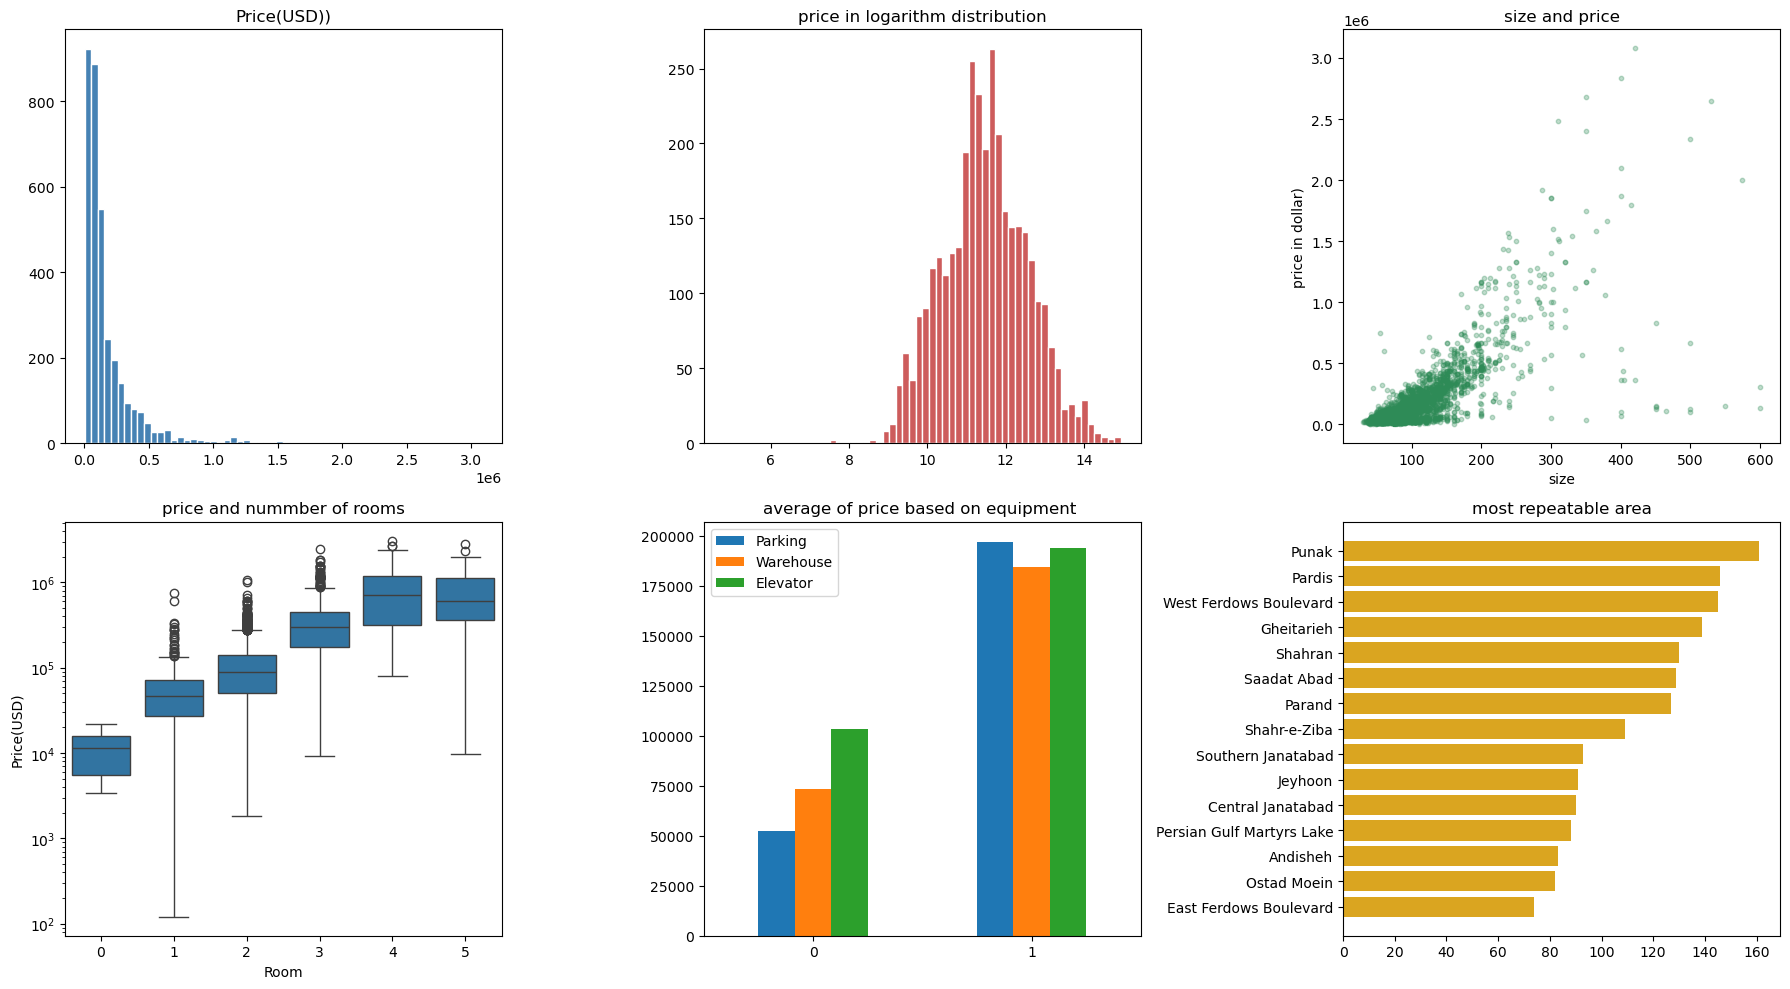

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].hist(df['Price(USD)'], bins=60, color='steelblue', edgecolor='white')
axes[0,0].set_title('Price(USD))')

axes[0,1].hist(np.log1p(df['Price(USD)']), bins=60, color='indianred', edgecolor='white')
axes[0,1].set_title('price in logarithm distribution')
axes[0,2].scatter(df['Area'], df['Price(USD)'], alpha=0.3, s=10, color='seagreen')
axes[0,2].set_title('size and price')
axes[0,2].set_xlabel('size')
axes[0,2].set_ylabel('price in dollar)')

sns.boxplot(x='Room', y='Price(USD)', data=df, ax=axes[1,0])
axes[1,0].set_title('price and nummber of rooms')
axes[1,0].set_yscale('log')

means = pd.DataFrame({
    'Parking': df.groupby('Parking')['Price(USD)'].mean(),
    'Warehouse': df.groupby('Warehouse')['Price(USD)'].mean(),
    'Elevator': df.groupby('Elevator')['Price(USD)'].mean(),
})
means.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('average of price based on equipment ')
axes[1,1].tick_params(axis='x', rotation=0)

top_addr = df['Address'].value_counts().head(15)
axes[1,2].barh(top_addr.index[::-1], top_addr.values[::-1], color='goldenrod')
axes[1,2].set_title('most repeatable area')

plt.tight_layout()
plt.show()

In [24]:
corr = df[['Area','Room','Parking','Warehouse','Elevator','Price(USD)']].corr()
corr['Price(USD)'].sort_values(ascending=False)

Price(USD)    1.000000
Area          0.750759
Room          0.574389
Parking       0.206460
Elevator      0.146155
Warehouse     0.122858
Name: Price(USD), dtype: float64

In [25]:
df['price_per_m2'] = df['Price(USD)'] / df['Area']
addr_stats = df.groupby('Address').agg(count=('Price(USD)','size'), avg_price=('Price(USD)','mean'),
                                        avg_price_per_m2=('price_per_m2','mean')).query('count>=10')
print('گران‌ترین مناطق (دلار به ازای هر متر):')
display(addr_stats.sort_values('avg_price_per_m2', ascending=False).head(10))
print()
print('ارزان‌ترین مناطق (دلار به ازای هر متر):')
display(addr_stats.sort_values('avg_price_per_m2', ascending=True).head(10))

گران‌ترین مناطق (دلار به ازای هر متر):


,count,avg_price,avg_price_per_m2
Address,,,
Zaferanieh,27,785838.271481,3790.462594
Elahieh,17,892878.430588,3740.419497
Velenjak,22,712712.121364,3722.663188
Kamranieh,14,610047.618571,3454.143946
Niavaran,68,663106.862794,3426.020637
Farmanieh,57,697242.689825,3410.992898
Aqdasieh,25,585999.999600,3029.528696
Shahrake Gharb,59,398996.045085,2773.011522
Dorous,13,624487.180000,2715.871742



ارزان‌ترین مناطق (دلار به ازای هر متر):


,count,avg_price,avg_price_per_m2
Address,,,
Parand,127,17453.018740,203.598805
Pakdasht,25,27426.665600,236.860450
Pardis,146,25927.397329,263.335014
Shahrake Qods,69,30030.724638,327.272926
Kahrizak,16,36073.957500,362.383755
Northern Chitgar,16,34489.584375,379.307837
Islamshahr,39,41914.102308,421.083079
Shahryar,12,51386.110833,436.817657
Andisheh,83,62586.426024,464.298246


## ۴. آماده‌سازی ویژگی‌ها برای مدل

از آنجایی که Address بیش از ۱۹۰ منطقه یکتا دارد، به جای One-Hot Encoding از دو روش استفاده می‌کنیم:
- **Frequency Encoding**: نسبت فراوانی هر منطقه در دیتاست
- **Target Encoding**: میانگین قیمت هر منطقه (فقط بر اساس داده train، برای جلوگیری از نشتی داده)


In [26]:
TARGET = 'Price(USD)'

addr_freq = df['Address'].value_counts(normalize=True)
df['Address_freq'] = df['Address'].map(addr_freq)

features_base = ['Area', 'Room', 'Parking', 'Warehouse', 'Elevator', 'Address_freq']
X = df[features_base + ['Address']].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

addr_mean_price = y_train.groupby(X_train['Address']).mean()
global_mean = y_train.mean()
X_train['Address_target_enc'] = X_train['Address'].map(addr_mean_price)
X_test['Address_target_enc'] = X_test['Address'].map(addr_mean_price).fillna(global_mean)

feature_cols = features_base + ['Address_target_enc']
X_train_f = X_train[feature_cols]
X_test_f = X_test[feature_cols]
X_train_f.head()

,Area,Room,Parking,Warehouse,Elevator,Address_freq,Address_target_enc
1444,200.0,3,1,1,1,0.002618,292295.237143
1675,95.0,2,1,1,1,0.004363,368411.110000
577,170.0,3,1,1,1,0.016579,695093.749792
2204,65.0,2,0,1,1,0.017452,45280.000444
980,140.0,3,1,1,1,0.046830,123189.567481


## ۵. آموزش و مقایسه مدل‌ها

In [27]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1),
}

results = []
for name, model in models.items():
    model.fit(X_train_f, y_train)
    preds = model.predict(X_test_f)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
    results.append({'Model': name, 'R2': r2, 'MAE ($)': mae, 'RMSE ($)': rmse, 'MAPE (%)': mape})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
results_df

,Model,R2,MAE ($),RMSE ($),MAPE (%)
3,Gradient Boosting,0.856698,39976.633466,100120.146383,29.139660
2,Random Forest,0.835011,39609.803914,107429.069294,26.651048
1,Decision Tree,0.826797,43669.925747,110071.045009,32.494975
4,XGBoost,0.807082,41503.023451,116166.565554,28.239462
0,Linear Regression,0.709194,62870.417217,142625.206596,67.982400


**نتیجه:** Gradient Boosting بهترین عملکرد را با R² ≈ 0.86 دارد.

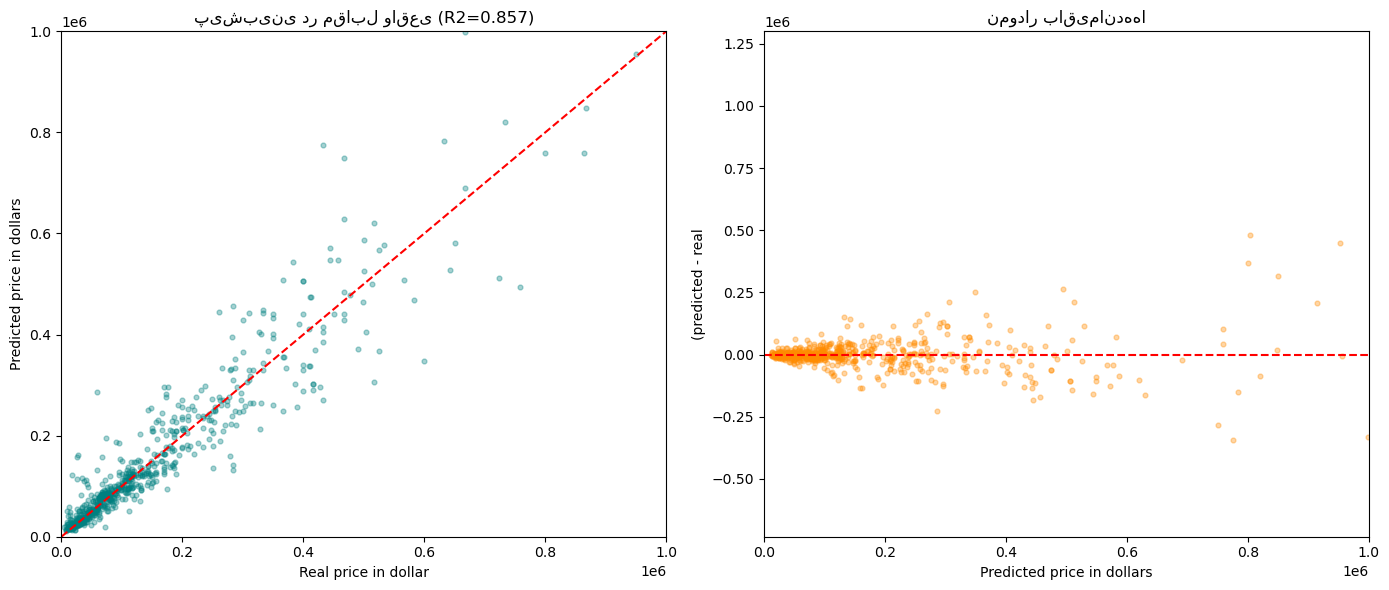

In [30]:
best_model = models['Gradient Boosting']
preds = best_model.predict(X_test_f)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(y_test, preds, alpha=0.35, s=12, color='teal')
lims = [0, 1_000_000]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_xlabel('Real price in dollar')
axes[0].set_ylabel('Predicted price in dollars')
axes[0].set_title(f'پیش‌بینی در مقابل واقعی (R2={r2_score(y_test, preds):.3f})')
axes[0].set_xlim(0, 1_000_000)
axes[0].set_ylim(0, 1_000_000)

residuals = y_test - preds
axes[1].scatter(preds, residuals, alpha=0.35, s=12, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted price in dollars')
axes[1].set_ylabel('(predicted - real')
axes[1].set_title('نمودار باقیمانده‌ها')
axes[1].set_xlim(0, 1_000_000)

plt.tight_layout()
plt.show()